In [1]:
import wrds
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
db = wrds.Connection()

Enter your WRDS username [27414]:zhoutengli
Enter your password:········
WRDS recommends setting up a .pgpass file.
Create .pgpass file now [y/n]?: y
pgpass file created at C:\Users\27414\AppData\Roaming\postgresql\pgpass.conf
Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done


In [9]:
data = db.raw_sql('''
select date, permno, prc
from crsp.dsf
where permno in (10107, 14593)
and date >= '2023-01-01'
and date <= '2024-01-01'
''')

In [11]:
data = data.dropna()
data['date'] = pd.to_datetime(data['date'])
data = data.sort_values(['permno', 'date'])  

In [28]:
# Split data into two companies
msft = data[data['permno'] == 10107].copy() # Microsoft
aapl = data[data['permno'] == 14593].copy() # Apple

In [29]:
# Print basic descriptive statistics
print("===== Microsoft (MSFT) 2023 Statistics =====")
print("Average Price:", round(msft['prc'].mean(), 2))
print("Highest Price:", round(msft['prc'].max(), 2))
print("Lowest Price:", round(msft['prc'].min(), 2))

print("\n===== Apple (AAPL) 2023 Statistics =====")
print("Average Price:", round(aapl['prc'].mean(), 2))
print("Highest Price:", round(aapl['prc'].max(), 2))
print("Lowest Price:", round(aapl['prc'].min(), 2))

===== Microsoft (MSFT) 2023 Statistics =====
Average Price: 313.95
Highest Price: 382.7
Lowest Price: 222.31

===== Apple (AAPL) 2023 Statistics =====
Average Price: 172.55
Highest Price: 198.11
Lowest Price: 125.02


In [30]:
# 1. Calculate daily percentage change (daily return)
# This measures how much the price changed each day
msft['daily_ret'] = msft['prc'].pct_change()
aapl['daily_ret'] = aapl['prc'].pct_change()

In [31]:
# 2. Calculate annualized volatility (risk measure)
# Volatility shows how much the price swings; higher = riskier
msft_vol = msft['daily_ret'].std() * (252 ** 0.5) # 252 trading days in a year
aapl_vol = aapl['daily_ret'].std() * (252 ** 0.5)

In [19]:
print("\n===== Risk Analysis =====")
print(f"MSFT Annualized Volatility: {msft_vol:.2%}")
print(f"AAPL Annualized Volatility: {aapl_vol:.2%}")


===== Risk Analysis =====
MSFT Annualized Volatility: 25.13%
AAPL Annualized Volatility: 19.95%


In [32]:
# 3. Calculate price correlation between the two stocks
# Correlation shows if they move together
combined = pd.merge(msft[['date', 'prc']], aapl[['date', 'prc']], on='date', suffixes=('_MSFT','_AAPL'))
correlation = combined['prc_MSFT'].corr(combined['prc_AAPL'])
print(f"Price Correlation: {correlation:.3f}")

Price Correlation: 0.948


In [33]:
# 4. 30-day moving average (trend indicator)
# Smoothes daily noise to see the true trend
msft['MA30'] = msft['prc'].rolling(window=30).mean()
aapl['MA30'] = aapl['prc'].rolling(window=30).mean()

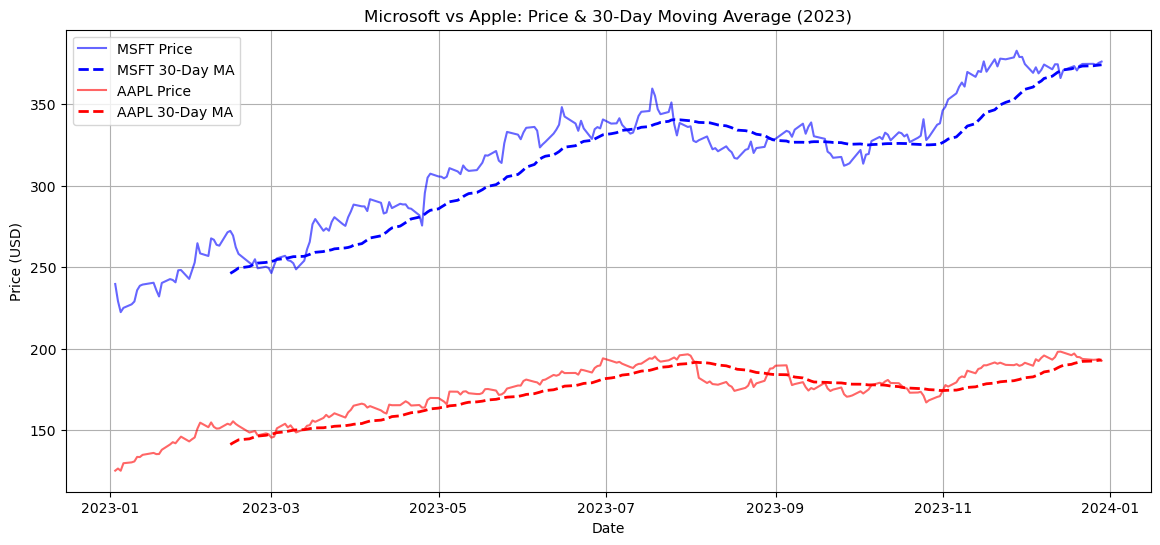

In [25]:
plt.figure(figsize=(14,6))
plt.plot(msft['date'], msft['prc'], label='MSFT Price', color='blue', alpha=0.6)
plt.plot(msft['date'], msft['MA30'], label='MSFT 30-Day MA', color='blue', linestyle='--', linewidth=2)
plt.plot(aapl['date'], aapl['prc'], label='AAPL Price', color='red', alpha=0.6)
plt.plot(aapl['date'], aapl['MA30'], label='AAPL 30-Day MA', color='red', linestyle='--', linewidth=2)
plt.title('Microsoft vs Apple: Price & 30-Day Moving Average (2023)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

In [34]:
# Calculate cumulative return (growth of $1 invested)
# This shows total performance over the whole year
msft['cum_ret'] = (1 + msft['daily_ret']).cumprod()
aapl['cum_ret'] = (1 + aapl['daily_ret']).cumprod()

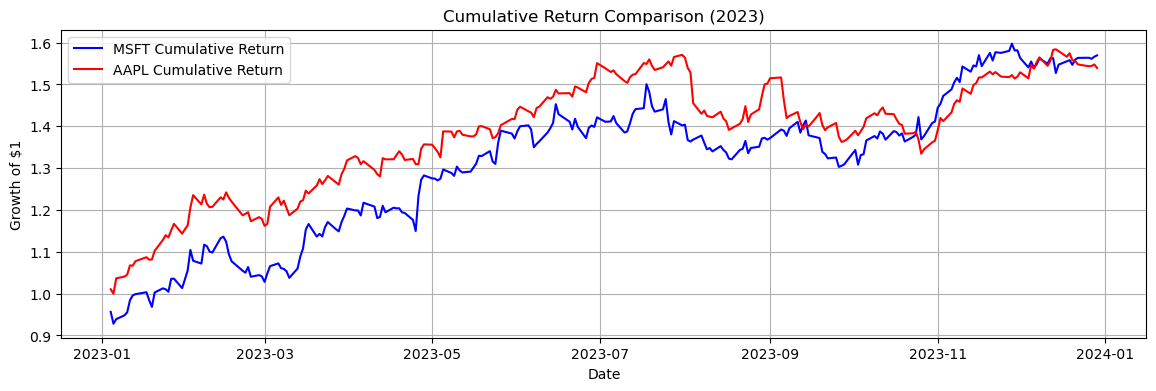

In [35]:
plt.figure(figsize=(14,4))
plt.plot(msft['date'], msft['cum_ret'], label='MSFT Cumulative Return', color='blue')
plt.plot(aapl['date'], aapl['cum_ret'], label='AAPL Cumulative Return', color='red')
plt.title('Cumulative Return Comparison (2023)')
plt.xlabel('Date')
plt.ylabel('Growth of $1')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
##  Key Findings 
##- **Volatility & Risk**:  
  Microsoft had an annualized volatility of **25.13%**, while Apple recorded **19.95%**. This shows Microsoft’s price was more volatile, reflecting higher risk driven by market optimism around AI developments, whereas Apple demonstrated more stable performance.

##- **Cumulative Return**:  
  By the end of 2023, Microsoft’s cumulative return reached approximately **1.60x**, outperforming Apple’s **1.56x**. This means a $1 investment in Microsoft grew to around $1.60, compared to $1.56 in Apple, showing Microsoft delivered stronger total returns despite higher risk.

##- **Trend & Stability**:  
  The 30-day moving average shows Microsoft maintained a stronger upward trend throughout the year, while Apple’s trend was more gradual. Microsoft’s price showed greater momentum, while Apple’s performance was more range-bound.

##- **Correlation**:  
  The two stocks exhibited a very strong positive correlation of **0.948**, indicating they were highly influenced by common sector-wide factors, such as macroeconomic conditions and investor sentiment toward the tech industry.
    
##  Limitations
- Only one year of data is analyzed
- No advanced forecasting models are used
- Analysis is limited to daily price data only